In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('train.txt',sep = ';',header = None,names = ['text','emotion'])

In [4]:
df.head()

,text,emotion
0,i didnt feel humiliated,sadness
1,i can go from feeling so hopeless to so damned...,sadness
2,im grabbing a minute to post i feel greedy wrong,anger
3,i am ever feeling nostalgic about the fireplac...,love
4,i am feeling grouchy,anger


In [5]:
df.isnull().sum()

text       0
emotion    0
dtype: int64

In [6]:
df['emotion'].unique()

<ArrowStringArray>
['sadness', 'anger', 'love', 'surprise', 'fear', 'joy']
Length: 6, dtype: str

In [7]:
unique_emotions = df['emotion'].unique()
emotion_numbers = {}
i = 0
for emo in unique_emotions:
  emotion_numbers[emo] = i
  i +=1

df['emotion'] = df['emotion'].map(emotion_numbers)

In [8]:
df

,text,emotion
0,i didnt feel humiliated,0
1,i can go from feeling so hopeless to so damned...,0
2,im grabbing a minute to post i feel greedy wrong,1
3,i am ever feeling nostalgic about the fireplac...,2
4,i am feeling grouchy,1
...,...,...
15995,i just had a very brief time in the beanbag an...,0
15996,i am now turning and i feel pathetic that i am...,0
15997,i feel strong and good overall,5
15998,i feel like this was such a rude comment and i...,1


In [9]:
df['text'] = df['text'].apply(lambda x : x.lower())

In [10]:
import string

def remove_punc(txt):
  return txt.translate(str.maketrans('','',string.punctuation))

In [11]:
df['text'] = df['text'].apply(remove_punc)

In [12]:
def remove_numbers(txt):
    new = ""
    for i in txt:
        if not i.isdigit():
            new = new + i
    return new

df['text'] = df['text'].apply(remove_numbers)

In [13]:
def remove_emojis(txt):
    new = ""
    for i in txt:
        if i.isascii():
            new += i
    return new

df['text'] = df['text'].apply(remove_emojis)

In [14]:
import nltk

In [15]:
from nltk.corpus import stopwords
from nltk.tokenize import word_tokenize

In [16]:
nltk.download('punkt')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\mousu\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!
[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\mousu\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [17]:
stop_words = set(stopwords.words('english'))

In [18]:
stop_words

{'a',
 'about',
 'above',
 'after',
 'again',
 'against',
 'ain',
 'all',
 'am',
 'an',
 'and',
 'any',
 'are',
 'aren',
 "aren't",
 'as',
 'at',
 'be',
 'because',
 'been',
 'before',
 'being',
 'below',
 'between',
 'both',
 'but',
 'by',
 'can',
 'couldn',
 "couldn't",
 'd',
 'did',
 'didn',
 "didn't",
 'do',
 'does',
 'doesn',
 "doesn't",
 'doing',
 'don',
 "don't",
 'down',
 'during',
 'each',
 'few',
 'for',
 'from',
 'further',
 'had',
 'hadn',
 "hadn't",
 'has',
 'hasn',
 "hasn't",
 'have',
 'haven',
 "haven't",
 'having',
 'he',
 "he'd",
 "he'll",
 "he's",
 'her',
 'here',
 'hers',
 'herself',
 'him',
 'himself',
 'his',
 'how',
 'i',
 "i'd",
 "i'll",
 "i'm",
 "i've",
 'if',
 'in',
 'into',
 'is',
 'isn',
 "isn't",
 'it',
 "it'd",
 "it'll",
 "it's",
 'its',
 'itself',
 'just',
 'll',
 'm',
 'ma',
 'me',
 'mightn',
 "mightn't",
 'more',
 'most',
 'mustn',
 "mustn't",
 'my',
 'myself',
 'needn',
 "needn't",
 'no',
 'nor',
 'not',
 'now',
 'o',
 'of',
 'off',
 'on',
 'once',
 'on

In [19]:
df.loc[1]['text']

'i can go from feeling so hopeless to so damned hopeful just from being around someone who cares and is awake'

In [20]:
def remove(txt):
  words = txt.split()
  cleaned = []
  for i in words:
    if not i in stop_words:
      cleaned.append(i)

  return ' '.join(cleaned)

In [21]:
df['text'] = df['text'].apply(remove)

In [22]:
df.loc[1]['text']

'go feeling hopeless damned hopeful around someone cares awake'

In [23]:
df.head()

,text,emotion
0,didnt feel humiliated,0
1,go feeling hopeless damned hopeful around some...,0
2,im grabbing minute post feel greedy wrong,1
3,ever feeling nostalgic fireplace know still pr...,2
4,feeling grouchy,1


In [24]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(df['text'], df['emotion'], test_size=0.20, random_state=42)

In [25]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

from sklearn.naive_bayes import MultinomialNB
from sklearn.metrics import accuracy_score

bow_vectorizer = CountVectorizer()
X_train_bow = bow_vectorizer.fit_transform(X_train)
X_test_bow = bow_vectorizer.transform(X_test)


nb_model = MultinomialNB()
nb_model.fit(X_train_bow, y_train)


pred_bow = nb_model.predict(X_test_bow)
print(accuracy_score(y_test, pred_bow))
     

0.768125


In [26]:
pred_bow

array([0, 5, 0, ..., 5, 5, 0], shape=(3200,))

In [27]:
tfidf_vectorizer = TfidfVectorizer()
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)
X_test_tfidf = tfidf_vectorizer.transform(X_test)


nb2_model = MultinomialNB()
nb2_model.fit(X_train_tfidf,y_train)

,"alpha alpha: float or array-like of shape (n_features,), default=1.0Additive (Laplace/Lidstone) smoothing parameter(set alpha=0 and force_alpha=True, for no smoothing).",1.0
,"force_alpha force_alpha: bool, default=TrueIf False and alpha is less than 1e-10, it will set alpha to1e-10. If True, alpha will remain unchanged. This may causenumerical errors if alpha is too close to 0... versionadded:: 1.2.. versionchanged:: 1.4 The default value of `force_alpha` changed to `True`.",True
,"fit_prior fit_prior: bool, default=TrueWhether to learn class prior probabilities or not.If false, a uniform prior will be used.",True
,"class_prior class_prior: array-like of shape (n_classes,), default=NonePrior probabilities of the classes. If specified, the priors are notadjusted according to the data.",None
Name,Type,Value
"class_count_ class_count_: ndarray of shape (n_classes,)Number of samples encountered for each class during fitting. Thisvalue is weighted by the sample weight when provided.","ndarray[float64](6,)","[3720.,1732.,1008., 459.,1540.,4341.]"
"class_log_prior_ class_log_prior_: ndarray of shape (n_classes,)Smoothed empirical log probability for each class.","ndarray[float64](6,)","[-1.24,-2. ,-2.54,-3.33,-2.12,-1.08]"
"classes_ classes_: ndarray of shape (n_classes,)Class labels known to the classifier","ndarray[int64](6,)","[0,1,2,3,4,5]"
"feature_count_ feature_count_: ndarray of shape (n_classes, n_features)Number of samples encountered for each (class, feature)during fitting. This value is weighted by the sample weight whenprovided.","ndarray[float64](6, 13361)","[[0.5 ,0.48,0. ,...,0. ,0. ,0.31], [0.48,0. ,0. ,...,0. ,0. ,0. ], [0. ,0. ,0. ,...,0. ,0.29,0. ], [0. ,0. ,0. ,...,0. ,0. ,0. ], [0.36,0. ,0. ,...,0. ,0. ,0. ], [0. ,0. ,0.3 ,...,0.26,0.7 ,0. ]]"
"feature_log_prob_ feature_log_prob_: ndarray of shape (n_classes, n_features)Empirical log probability of featuresgiven a class, ``P(x_i|y)``.","ndarray[float64](6, 13361)","[[ -9.65, -9.67,-10.05,...,-10.05,-10.05, -9.79], [ -9.41, -9.8 , -9.8 ,..., -9.8 , -9.8 , -9.8 ], [ -9.69, -9.69, -9.69,..., -9.69, -9.44, -9.69], [ -9.59, -9.59, -9.59,..., -9.59, -9.59, -9.59], [ -9.47, -9.77, -9.77,..., -9.77, -9.77, -9.77], [-10.14,-10.14, -9.88,..., -9.91, -9.61,-10.14]]"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,13361


In [28]:
y_pred = nb2_model.predict(X_test_tfidf)

In [29]:
print(accuracy_score(y_test, y_pred))

0.6609375


In [30]:
from sklearn.linear_model import LogisticRegression

In [31]:
logistic_model = LogisticRegression(max_iter=1000)

In [32]:
logistic_model.fit(X_train_tfidf,y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

In [33]:
log_pred = logistic_model.predict(X_test_tfidf)

In [34]:
print(accuracy_score(y_test,log_pred ))

0.8628125


In [35]:
from sklearn.svm import LinearSVC

svm_model = LinearSVC()

svm_model.fit(X_train_tfidf, y_train)

svm_pred = svm_model.predict(X_test_tfidf)

print(accuracy_score(y_test, svm_pred))

0.891875


In [36]:
tfidf_bigram = TfidfVectorizer(ngram_range=(1, 2))

X_train_bigram = tfidf_bigram.fit_transform(X_train)
X_test_bigram = tfidf_bigram.transform(X_test)

In [37]:
svm_bigram = LinearSVC()

svm_bigram.fit(X_train_bigram, y_train)

svm_bigram_pred = svm_bigram.predict(X_test_bigram)

print(accuracy_score(y_test, svm_bigram_pred))

0.901875


In [38]:
from sklearn.svm import LinearSVC

C_values = [0.5, 1, 1.5, 2]

for c in C_values:
    model = LinearSVC(C=c)
    model.fit(X_train_bigram, y_train)

    pred = model.predict(X_test_bigram)

    accuracy = accuracy_score(y_test, pred)

    print("C =", c, "Accuracy =", accuracy)

C = 0.5 Accuracy = 0.898125
C = 1 Accuracy = 0.901875
C = 1.5 Accuracy = 0.9009375
C = 2 Accuracy = 0.9009375


In [39]:
from sklearn.metrics import classification_report

final_svm = LinearSVC(C=1.0)

final_svm.fit(X_train_bigram, y_train)

final_pred = final_svm.predict(X_test_bigram)

print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

           0       0.94      0.94      0.94       946
           1       0.89      0.89      0.89       427
           2       0.85      0.78      0.81       296
           3       0.83      0.73      0.78       113
           4       0.87      0.84      0.86       397
           5       0.90      0.95      0.93      1021

    accuracy                           0.90      3200
   macro avg       0.88      0.86      0.87      3200
weighted avg       0.90      0.90      0.90      3200



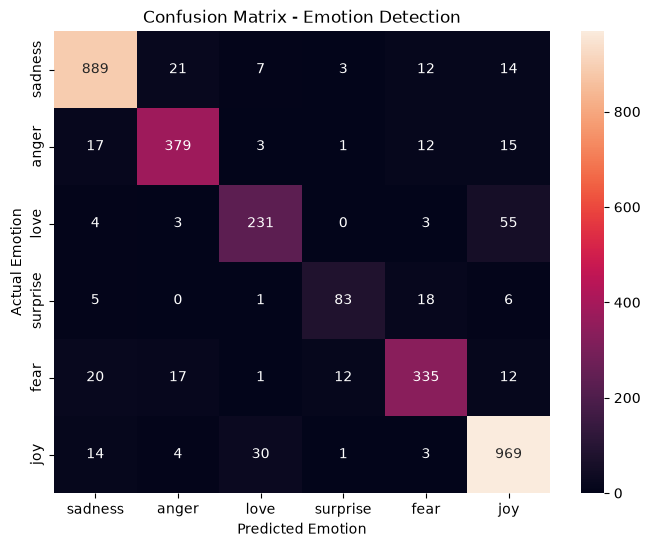

In [40]:
from sklearn.metrics import confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, final_pred)

plt.figure(figsize=(8, 6))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    xticklabels=['sadness', 'anger', 'love', 'surprise', 'fear', 'joy'],
    yticklabels=['sadness', 'anger', 'love', 'surprise', 'fear', 'joy']
)

plt.xlabel('Predicted Emotion')
plt.ylabel('Actual Emotion')
plt.title('Confusion Matrix - Emotion Detection')

plt.show()

In [41]:
import joblib

joblib.dump(final_svm, "emotion_model.pkl")
joblib.dump(tfidf_bigram, "tfidf_vectorizer.pkl")

['tfidf_vectorizer.pkl']